Equipo 8
Integrantes:


*   Alesio Nehuen Benitez
*   Lautaro Cecotti
* Ana Emilia Espinosa



#Avance 1

1. Obtener un dataset sucio (github, generado, Kaggle, del gobierno, etc).
2. Revisar la estructura del dataset (dimensiones, nombres de columnas, tipos de datos).
3. Identificar valores faltantes, duplicados y posibles errores.
4. Elaborar un listado escrito de problemas detectados.

In [ ]:
import pandas as pd
import numpy as np

from google.colab import files


datos= pd.read_csv('/futbolargentino.csv', sep=";")
datos.head()
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12092 entries, 0 to 12091
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Jugadores         12092 non-null  object
 1   Posicion          12092 non-null  object
 2   Edad              12092 non-null  object
 3   Altura            12092 non-null  object
 4   Pie               11735 non-null  object
 5   Fichado           12092 non-null  object
 6   Equipo Anterior   10556 non-null  object
 7   Valor de mercado  12092 non-null  object
 8   Temporada         12092 non-null  int64 
 9   Club              12091 non-null  object
dtypes: int64(1), object(9)
memory usage: 944.8+ KB


Se eligió un dataset que cuenta con datos de jugadores presentes en el futbol argentino.

Las dimensiones del mismo son:

-12092 Filas

-10 Columnas

Los datos en un comienzo son todos tipo object. Pero luego de transformarlo hay datos tipo float (Columnas: Altura, Valor de mercado). Tipo int (Columnas: Edad, Temporada). Tipo string (Columnas: Jugadores, Posicion, Pie, Equipo Anterior, Club). Y tipo datetime (Columna: Fichado)

In [ ]:
#Observar Valores Faltantes
datos.isna().sum() #Haciendo una exploración visual se observa que hay valores faltantes puestos como '-'

,0
Jugadores,0
Posicion,0
Edad,0
Altura,0
Pie,357
Fichado,0
Equipo Anterior,1536
Valor de mercado,0
Temporada,0
Club,1


In [ ]:
(datos == '-').sum() #Comprobación de que los valores puestos como '-' se consideran NaN
#Ya que el número de NaN (isna.().sum()) es igual a este valor, se confirma que son equivalentes.

#Los valores NaN totales son:
#Altura hay 268 NaN
#Pie hay 424.
#Fichado hay 1536
# Valor de mercado hay 1704
# Club hay 1. En el resto no hay.

,0
Jugadores,0
Posicion,0
Edad,0
Altura,268
Pie,66
Fichado,1539
Equipo Anterior,0
Valor de mercado,1704
Temporada,0
Club,0


In [ ]:
#Identificación de Errores
datos['Equipo Anterior'].unique() #Se utilizó este comando, variando la columna cada vez y se realizó una exploración visual con cada resultado
#Para identificar posibles errores en los mismos.

array(['Inferiores Argentinos Juniors', nan, 'SSC Nápoles', 'inactivo',
       'CD Godoy Cruz Antonio Tomba', 'Libre', 'CA Rosario Central',
       'Club Atlético Unión', 'Quilmes Atlético Club',
       'Sport Club Corinthians Paulista', 'CA Boca Juniors',
       'CA Platense', 'FC Lorient', 'Nueva Chicago', 'Club Olimpo',
       'CA San Martín San Juan', 'Club Sportivo Ben Hur',
       'Club Atlético San Telmo', 'Libre35 mil €', 'Millonarios FC',
       'Indios de Ciudad Juárez - 2011', 'Club Olimpia Asunción',
       'CD Everton', 'Club de Gimnasia y Esgrima La Plata',
       "CA Newell's Old Boys", 'Atlético de Rafaela', 'Club Nacional',
       'Club Almirante Brown', 'Tiburones Rojos de Veracruz',
       'CSD Colo Colo', 'Córdoba CF', 'CD Cruz Azul', 'CA Independiente',
       'Atlas Guadalajara', 'Club Atlético Tucumán',
       'Club Atlético Boca Unidos', 'Barcelona SC Guayaquil',
       'Defensor Sporting Club', 'CFR Cluj', 'Club Atlético Lanús',
       'San Luis FC', 'Instituto

#Errores Encontrados

*   Hay valores faltantes NaN
*   Hay valores faltantes marcados como '-'
* La columna 'Altura' presenta la coma decimal en lugar del punto decimal
* En la columna 'Edad' se registran jugadores con edades superiores a 47 años y con edades de fallecimiento.
* Algunos equipos en la columna 'Equipo Anterior', presentan la misma raíz pero luego sigue la raíz de nombre, pero luego continua con la categoría o el año en el que jugó el jugador.
Por ejemplo: "Manchester City U23" o "Metalist Kharkiv (- 2016)".
Además de eso, los jugadores que se encontraban libres aparecen con el siguiente formato 'Libre50 mil €' pero variando lo que acompaña a 'Libre'.




# Avance 2

1. Resolver valores faltantes (decidir imputación, reemplazo o eliminación).
2. Corregir categorías inconsistentes (ejemplo: “M”, “Masculino”, “m”).
3. Tratar outliers (ejemplo: edades imposibles, pesos irreales).
4. Eliminar duplicados.
5. Explicar brevemente las decisiones tomadas en cada paso.



In [ ]:
import pandas as pd
import numpy as np

from google.colab import files


datos= pd.read_csv('/futbolargentino.csv', sep=";")
datos.head()

,Jugadores,Posicion,Edad,Altura,Pie,Fichado,Equipo Anterior,Valor de mercado,Temporada,Club
0,Nicolás Gianni,Centrocampista,25,"1,75",derecho,01/07/2000,Inferiores Argentinos Juniors,800000,2008,Argentinos Juniors
1,Maximiliano Sola,Defensa,22,"1,8",izquierdo,-,NaN,-,2008,Argentinos Juniors
2,Nicolás Navarro,Portero,23,"1,9",derecho,24/07/2010,SSC Nápoles,2000000,2008,Argentinos Juniors
3,Juan Carrera,Portero,27,"1,91",derecho,01/01/2005,inactivo,800000,2008,Argentinos Juniors
4,Sebastián Torrico,Portero,28,"1,86",derecho,01/01/2009,CD Godoy Cruz Antonio Tomba,250000,2008,Argentinos Juniors


- Identificación de valores faltantes



In [ ]:
datoscopia= datos.copy()
datoscopia.tail()

,Jugadores,Posicion,Edad,Altura,Pie,Fichado,Equipo Anterior,Valor de mercado,Temporada,Club
12087,Sebastián Sosa Sánchez,Delantero centro,29,"1,87",derecho,20/01/2022,CA Boston River,1300000,2022,Velez Sarsfield
12088,Lucas Pratto,Delantero centro,21,"1,86",derecho,27/08/2021,Libre,450000,2022,Velez Sarsfield
12089,Santiago Castro,Delantero centro,22,"1,79",derecho,01/01/2022,CA Vélez Sarsfield Inferiores,100000,2022,Velez Sarsfield
12090,Mateo Pellegrino,Delantero centro,29,"1,93",izquierdo,-,NaN,50000,2022,Velez Sarsfield
12091,Abiel Osorio,Delantero centro,24,"1,82",derecho,01/01/2022,CA Vélez Sarsfield Inferiores,25000,2022,Velez Sarsfield


In [ ]:
datoscopia.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12092 entries, 0 to 12091
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Jugadores         12092 non-null  object
 1   Posicion          12092 non-null  object
 2   Edad              12092 non-null  object
 3   Altura            12092 non-null  object
 4   Pie               11735 non-null  object
 5   Fichado           12092 non-null  object
 6   Equipo Anterior   10556 non-null  object
 7   Valor de mercado  12092 non-null  object
 8   Temporada         12092 non-null  int64 
 9   Club              12091 non-null  object
dtypes: int64(1), object(9)
memory usage: 944.8+ KB


Se observan valores de datos faltantes puestos como " - ", por lo que se van a reemplazar esos valores por NaN

In [ ]:
datoscopia.replace('-', np.nan, inplace=True)
datoscopia.tail()

,Jugadores,Posicion,Edad,Altura,Pie,Fichado,Equipo Anterior,Valor de mercado,Temporada,Club
12087,Sebastián Sosa Sánchez,Delantero centro,29,"1,87",derecho,20/01/2022,CA Boston River,1300000,2022,Velez Sarsfield
12088,Lucas Pratto,Delantero centro,21,"1,86",derecho,27/08/2021,Libre,450000,2022,Velez Sarsfield
12089,Santiago Castro,Delantero centro,22,"1,79",derecho,01/01/2022,CA Vélez Sarsfield Inferiores,100000,2022,Velez Sarsfield
12090,Mateo Pellegrino,Delantero centro,29,"1,93",izquierdo,NaN,NaN,50000,2022,Velez Sarsfield
12091,Abiel Osorio,Delantero centro,24,"1,82",derecho,01/01/2022,CA Vélez Sarsfield Inferiores,25000,2022,Velez Sarsfield


In [ ]:
datoscopia.isna().sum()

,0
Jugadores,0
Posicion,0
Edad,0
Altura,268
Pie,423
Fichado,1539
Equipo Anterior,1536
Valor de mercado,1704
Temporada,0
Club,1


En la columna Altura hay 268 NaN, en Pie hay 424. En fichado hay 1536, en el valor de mercado hay 1704 y en club hay 1. Ahora vamos a contar cuantos valores repetidos hay

In [ ]:
True in datoscopia['Jugadores'].duplicated() #Se buscan Jugadores duplicados

False

No se encuentran filas repetidas. Ahora hay que verificar que haya posibles errores. Consideraremos erroes a filas completas de Nan o con más de 4 Nan y las eliminamos.

In [ ]:
datoscopia.dropna(how='all').info() #No hay ninguna fila completa de NaN
a = datoscopia[datoscopia.isna().sum(axis=1) <= 4]
a.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12092 entries, 0 to 12091
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Jugadores         12092 non-null  object
 1   Posicion          12092 non-null  object
 2   Edad              12092 non-null  object
 3   Altura            11824 non-null  object
 4   Pie               11669 non-null  object
 5   Fichado           10553 non-null  object
 6   Equipo Anterior   10556 non-null  object
 7   Valor de mercado  10388 non-null  object
 8   Temporada         12092 non-null  int64 
 9   Club              12091 non-null  object
dtypes: int64(1), object(9)
memory usage: 944.8+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 11991 entries, 0 to 12091
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Jugadores         11991 non-null  object
 1   Posicion          11991 non-null  object

Hay un total de 101 filas que tienen 4 o más valores NaN. Que serán consideradas como errores y eliminadas

In [ ]:
#Se van a tratar los valores NaN de la sigueinte manera: Si es de cualquier columna que no sea valor de mercado, se elimina la fila entera. Pero si es de valor de mercado, se toma el promedio del club
datoscopia['Valor de mercado']=datoscopia['Valor de mercado'].astype(float)
datoscopia['Valor de mercado'] = datoscopia['Valor de mercado'].fillna(
    datoscopia.groupby('Club')['Valor de mercado'].transform('mean')
)


datoscopia=datoscopia.dropna(subset=["Altura", "Pie", "Fichado", "Equipo Anterior", "Club"]) #Elimina las filas donde haya un NaN en estas columnas, debido a que no se pueden inferir de ninguna manera
datoscopia.head()

datoscopia.isna().sum() #Se comprueba que ya no haya NaNs

,0
Jugadores,0
Posicion,0
Edad,0
Altura,0
Pie,0
Fichado,0
Equipo Anterior,0
Valor de mercado,0
Temporada,0
Club,0


In [ ]:
datoscopia['Altura']=datoscopia['Altura'].astype(str).str.replace(',', '.').astype(float) #Se convierte la coma decimal a punto decimal y así se lo puede definir como float a la altura
datoscopia["Altura"]=datoscopia["Altura"].round(2) #Se redondea la altura a dos dígitos después del punto
datoscopia["Altura"].unique()

array([1.75, 1.9 , 1.91, 1.86, 1.84, 1.85, 1.76, 1.8 , 1.82, 1.93, 1.66,
       1.74, 1.78, 1.79, 1.94, 1.7 , 1.77, 1.67, 1.64, 1.69, 1.99, 1.87,
       1.63, 1.81, 1.72, 1.71, 1.83, 1.68, 1.95, 1.88, 1.73, 1.97, 1.58,
       1.89, 1.92, 1.61, 1.62, 1.98, 1.65, 1.6 , 1.96, 1.59, 1.56])

In [ ]:
#Se realiza el tratamiento de errores en la columna 'Equipo Anterior'
datoscopia['Equipo Anterior']=datoscopia['Equipo Anterior'].astype(str) #Definimos la columna como string


datoscopia["Equipo Anterior"] = datoscopia["Equipo Anterior"].str.replace(r"^Libre.*", "Libre", regex=True) #Se consideran los datos cuya raíz de palabra sea 'Libre' y se ignora todo lo que siga después de eso, dejando solo 'Libre'
datoscopia["Equipo Anterior"] = datoscopia["Equipo Anterior"].str.replace(r"\s*-\s*\d{4}", "", regex=True) # Se buscan los equipos que tengan una raíz y después siga con un '-' y un año. Dejando unicamente el nombre del equipo
datoscopia["Equipo Anterior"] = datoscopia["Equipo Anterior"].str.replace(r"\s*\(.*?\)", "", regex=True) #Se eliminan los equipos que tienen nombre en paréntesis
datoscopia["Equipo Anterior"] = datoscopia["Equipo Anterior"].str.replace(r"\s*U\d+\w*", "", regex=True) #Se eliminan las categorias dentro del nombre del club (Por ejemplo Manchester City U23, se elimina el U23)
datoscopia["Equipo Anterior"] = datoscopia["Equipo Anterior"].str.strip() #Se quitan espacios al principio y al final

datoscopia['Equipo Anterior'].unique()

array(['Inferiores Argentinos Juniors', 'SSC Nápoles', 'inactivo',
       'CD Godoy Cruz Antonio Tomba', 'Libre', 'CA Rosario Central',
       'Club Atlético Unión', 'Quilmes Atlético Club',
       'Sport Club Corinthians Paulista', 'CA Boca Juniors',
       'CA Platense', 'FC Lorient', 'Nueva Chicago', 'Club Olimpo',
       'CA San Martín San Juan', 'Club Sportivo Ben Hur',
       'Club Atlético San Telmo', 'Millonarios FC',
       'Club Olimpia Asunción', 'CD Everton',
       'Club de Gimnasia y Esgrima La Plata', "CA Newell's Old Boys",
       'Club Almirante Brown', 'Tiburones Rojos de Veracruz',
       'CSD Colo Colo', 'Córdoba CF', 'CD Cruz Azul', 'CA Independiente',
       'Atlas Guadalajara', 'Club Atlético Tucumán',
       'Club Atlético Boca Unidos', 'Barcelona SC Guayaquil',
       'Defensor Sporting Club', 'CFR Cluj', 'Club Atlético Lanús',
       'San Luis FC', 'Instituto AC Córdoba',
       'Comisión de Actividades Infantiles', 'CA San Lorenzo de Almagro',
       'Racing 

In [ ]:
datoscopia['Valor de mercado']=datoscopia['Valor de mercado'].astype(int)
datoscopia.head()

,Jugadores,Posicion,Edad,Altura,Pie,Fichado,Equipo Anterior,Valor de mercado,Temporada,Club
0,Nicolás Gianni,Centrocampista,25,1.75,derecho,01/07/2000,Inferiores Argentinos Juniors,800000,2008,Argentinos Juniors
2,Nicolás Navarro,Portero,23,1.90,derecho,24/07/2010,SSC Nápoles,2000000,2008,Argentinos Juniors
3,Juan Carrera,Portero,27,1.91,derecho,01/01/2005,inactivo,800000,2008,Argentinos Juniors
4,Sebastián Torrico,Portero,28,1.86,derecho,01/01/2009,CD Godoy Cruz Antonio Tomba,250000,2008,Argentinos Juniors
5,Diego Morales,Portero,25,1.84,derecho,01/01/2002,Inferiores Argentinos Juniors,75000,2008,Argentinos Juniors


Lo que hacemos ahora es el tratamiento de Outliers. Para detectar si hay alguno. Esto solo lo haremos para las columnas con variables numéricas

In [ ]:
import pandas as pd
datoscopia = datoscopia[(datoscopia["Edad"] != "†30") & (datoscopia["Edad"] != "†26")] #En la variable edad se hallaban edades con fecha de fallecimiento, por lo que estos datos fueron eliminados
datoscopia['Edad']=datoscopia['Edad'].astype(int)
datoscopia['Valor de mercado']=datoscopia['Valor de mercado'].astype(int)
datoscopia['Altura']=datoscopia['Altura'].astype(float)

columnas = ["Edad", "Altura"] #No considero valor de mercado pq son precios razonables

# Copia para trabajar
datos_filt = datoscopia.copy()

for col in columnas:
    media = datos_filt[col].mean()
    desviacion = datos_filt[col].std()

    k = 4  #Consideramos un umbral de 4 desviaciones estandares para detectar outliers y marcamos limiten
    limite_inferior = media - k * desviacion
    limite_superior = media + k * desviacion

    # Filtrar filas que estén dentro del rango
    datos_filt = datos_filt[(datos_filt[col] >= limite_inferior) &
                              (datos_filt[col] <= limite_superior)]


In [ ]:
datoscopia=datos_filt
datoscopia=datoscopia.reset_index(drop=True)#Reseteo los indices
datoscopia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10352 entries, 0 to 10351
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Jugadores         10352 non-null  object 
 1   Posicion          10352 non-null  object 
 2   Edad              10352 non-null  int64  
 3   Altura            10352 non-null  float64
 4   Pie               10352 non-null  object 
 5   Fichado           10352 non-null  object 
 6   Equipo Anterior   10352 non-null  object 
 7   Valor de mercado  10352 non-null  int64  
 8   Temporada         10352 non-null  int64  
 9   Club              10352 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 808.9+ KB


# Avance 3

1. Calcular estadísticas descriptivas de las variables numéricas (media, mediana, desviación estándar).
2. Analizar la frecuencia de categorías en variables cualitativas.
3. Explorar relaciones entre variables (correlaciones o cruces entre columnas relevantes).
4. Escribir un análisis de los principales hallazgos.

In [ ]:
#Inciso 1
#Se calculan estadisticas descriptivas para las columnas: 'Edad, 'Altura' y 'Valor de mercado'
columnas_numericas = ["Edad", "Altura", "Valor de mercado"]
datoscopia[columnas_numericas].describe()
for columna in columnas_numericas:
    media = datoscopia[columna].mean()
    mediana = datoscopia[columna].median()
    desviacion_estandar = datoscopia[columna].std()
    print(f"Estadísticas para la columna '{columna}':")
    print(f"Media: {media}")
    print(f"Mediana: {mediana}")
    print(f"Desviación Estándar: {desviacion_estandar}")

Estadísticas para la columna 'Edad':
Media: 25.065397990726428
Mediana: 24.0
Desviación Estándar: 4.955416393572321
Estadísticas para la columna 'Altura':
Media: 1.791876931993818
Mediana: 1.79
Desviación Estándar: 0.06659445102476808
Estadísticas para la columna 'Valor de mercado':
Media: 1134972.1699188564
Mediana: 700000.0
Desviación Estándar: 1570117.2809063955


In [ ]:
#Inciso 2
#Se calculan las frecuencias para las variables cualitativas
columnas_cuali=['Posicion', 'Pie', 'Equipo Anterior', 'Club']
for columna in columnas_cuali:
    frecuencia = datoscopia[columna].value_counts(normalize=True)*100
    print(f"Frecuencia de categorías en la columna '{columna}'%:")
    print(frecuencia)
    print()

Frecuencia de categorías en la columna 'Posicion'%:
Posicion
Defensa central         17.899923
Delantero centro        15.687790
Mediocentro              9.862828
Pivote                   9.225270
Mediocentro ofensivo     9.157651
Portero                  9.099691
Lateral izquierdo        7.042117
Lateral derecho          6.732998
Extremo izquierdo        5.197063
Extremo derecho          4.791345
Interior derecho         2.241113
Interior izquierdo       1.999614
Mediapunta               0.502318
Centrocampista           0.289799
Delantero                0.202859
Defensa                  0.067620
Name: proportion, dtype: float64

Frecuencia de categorías en la columna 'Pie'%:
Pie
derecho        74.362442
izquierdo      23.251546
ambidiestro     2.386012
Name: proportion, dtype: float64

Frecuencia de categorías en la columna 'Equipo Anterior'%:
Equipo Anterior
Libre                                             19.039799
Club Atlético Lanús Inferiores                     2.357032
Inferi

In [ ]:
#Inciso 3. Se calcula la correlacion de variables numéricas
correlacion= datoscopia[columnas_numericas].corr()
print(correlacion) #Se correlacionan mal todas


                      Edad    Altura  Valor de mercado
Edad              1.000000  0.010603         -0.022241
Altura            0.010603  1.000000         -0.071607
Valor de mercado -0.022241 -0.071607          1.000000


#Sección Final


1. Crear al menos 3 visualizaciones diferentes:
   - Un histograma o boxplot de variables numéricas.
   - Un gráfico de barras de variables categóricas.
   - Un heatmap o gráfico de dispersión de relaciones entre variables.
2. Explicar qué muestra cada gráfico y qué conclusiones se pueden extraer.
3. Redactar un informe final (máx. 1 página) que incluya:
   - Resumen de problemas detectados y cómo fueron resueltos.
   - Principales hallazgos del análisis.
   - Conclusiones extraídas de las visualizaciones.

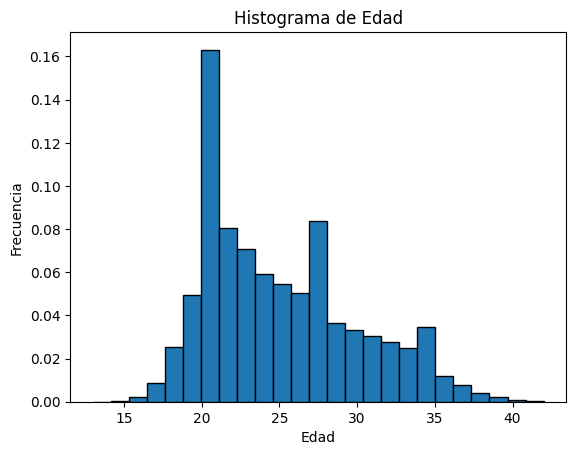

In [ ]:

import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
#Realizamos un histograma de la columna edad para ver la distribución de la misma.
plt.hist(datoscopia['Edad'],bins=25, density=True, edgecolor='black')
plt.title('Histograma de Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()



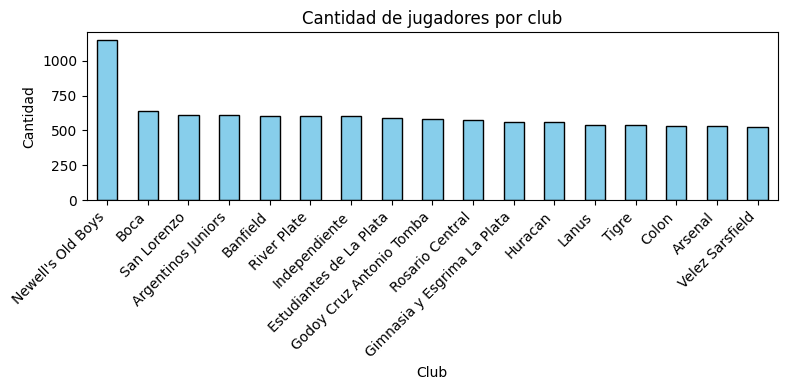

In [ ]:
#Realizamos un gráfico de barras de la columna Club, para observar que club tuvo el mayor número de jugadores

datoscopia['Club'].value_counts().plot(kind='bar', figsize=(8,4), color='skyblue', edgecolor='black')

plt.title('Cantidad de jugadores por club')
plt.xlabel('Club')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

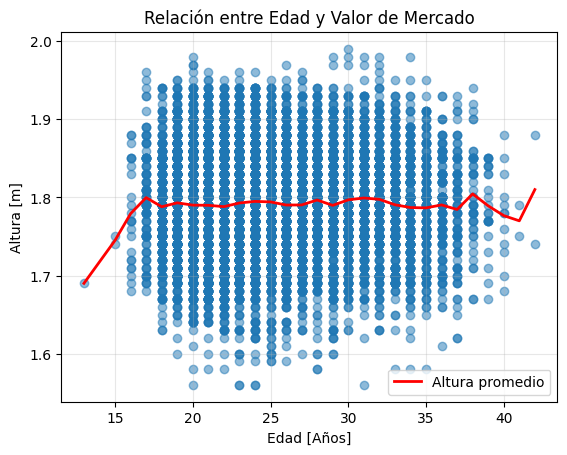

In [ ]:
#Se realiza la gráfica de dispersion entre la edad y la altura para observar si hay una correlación entre los mismos, lo cuál no se pudo comprobar
#Además se gráfico encima de la gráfica, la curva de alturas promedio para cada edad, para poder comprender un poco mejor los datos.
plt.scatter(datoscopia['Edad'], datoscopia['Altura'], alpha=0.5)
plt.title('Relación entre Edad y Valor de Mercado')
plt.xlabel('Edad [Años]')
plt.ylabel('Altura [m]')
promedios = datoscopia.groupby('Edad')['Altura'].mean()
plt.plot(promedios.index, promedios.values, color='red', linewidth=2, label='Altura promedio')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.3)
plt.show()